## **Task 3: Customer Segmentation Using RFM Analysis**
**Description:**
- Dataset (Recommended): Online  Retail Dataset (UCI)
- Use a sales dataset to analyze customer behavior based on:
 - Recency: How recently a customer made a purchase
 - Frequency: How often they made purchases
 - Monetary: How much money they spent
- Assign scores to each customer using these three metrics
- Group similar customers based on their scores
- Suggest simple marketing ideas for each group (e.g. discounts for loyal buyers, re-engagement for inactive ones)
**Tools & Libraries:**
- python ,pandas ,seaborn
**Covered Topics**
- Feature engineering | Segmentation logic | Customer analytics
**Bonus**
- Visualize RFM segments with heatmaps or bar charts


In [2]:
import pandas as pd 

In [3]:
Data = pd.read_csv(
    "dataset/RetailData.csv",
    encoding="ISO-8859-1"
)

Data.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


**The dataset contains non-UTF-8 encoded characters, therefore ISO-8859-1 encoding was used to successfully load the data.**

In [4]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
Data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

#### Handel Missing Value in Description  and CustomerID 
- DROP MISSING CustomerID
- HANDLE Description
 
**Records with missing CustomerID were removed since customer-level analysis cannot be performed without unique customer identifiers. Missing product descriptions were not critical for RFM analysis.**

In [6]:
Data = Data.dropna(subset=['CustomerID'])
Data["Description"]=Data["Description"].fillna("Unknown")

In [7]:
Data.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [8]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


### clean negative values

In [9]:
Data = Data[Data['Quantity'] > 0]
Data = Data[Data['UnitPrice'] > 0]
Data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397884 non-null  object 
 1   StockCode    397884 non-null  object 
 2   Description  397884 non-null  object 
 3   Quantity     397884 non-null  int64  
 4   InvoiceDate  397884 non-null  object 
 5   UnitPrice    397884 non-null  float64
 6   CustomerID   397884 non-null  float64
 7   Country      397884 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.3+ MB


**Transactions with non-positive quantity or unit price were removed to exclude cancelled orders and invalid sales, ensuring accurate calculation of monetary and frequency metrics.**

#### convert InvoiceDate

In [10]:
Data['InvoiceDate'] = pd.to_datetime(Data['InvoiceDate'])
Data.info()
Data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


**The dataset contains 397,884 valid retail transactions with complete customer information. The InvoiceDate column was converted to datetime format to enable time-based analysis such as recency calculation.**

ADD Columns TOTAL PRICE 

In [11]:
Data['TotalPrice'] = Data['Quantity'] * Data['UnitPrice']
Data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [12]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   TotalPrice   397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


## CREATE RFM TABLE

**SET REFERENCE DATE**

In [13]:
reference_date = Data['InvoiceDate'].max() + pd.Timedelta(days=1)
reference_date


Timestamp('2011-12-10 12:50:00')

**Recency was calculated as the number of days since the customer’s most recent purchase, using the last transaction date in the dataset plus one day as the reference point.**

**CustomerID** was converted to an integer to remove unnecessary decimal values introduced by missing data and to ensure clean grouping and reliable merging during RFM analysis.


In [14]:
# Convert CustomerID to integer for cleaner display
Data['CustomerID'] = Data['CustomerID'].astype(int)
Data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int32         
 7   Country      397884 non-null  object        
 8   TotalPrice   397884 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(4)
memory usage: 28.8+ MB


In [15]:
# Calculate RFM metrics
rfm = Data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                 # Frequency (Unique orders)
    'TotalPrice': 'sum'                                      # Monetary
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# View the result
print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346           326          1  77183.60
12347             2          7   4310.00
12348            75          4   1797.24
12349            19          1   1757.55
12350           310          1    334.40


### **RFM Metrics Calculation**
We calculated the **Recency, Frequency, and Monetary (RFM)** metrics for each customer using the sales dataset.

* **Recency** measures how recently a customer made their last purchase, calculated as the number of days between a reference date and their most recent order. For example, `CustomerID 12347` has a recency of 2 days, meaning they purchased very recently, while `CustomerID 12346` has 326 days, indicating a long gap since their last purchase.
* **Frequency** counts how many unique orders a customer has made. Customers with higher frequency, like `CustomerID 12347` with 7 orders, are more loyal.
* **Monetary** sums the total amount spent by the customer. For instance, `CustomerID 12346` spent 77,183.60, making them one of the highest-value customers, while `CustomerID 12350` spent 334.40.

The resulting `rfm` table contains one row per customer with these three metrics, which will later be used to **score and segment customers** based on their purchasing behavior.



In [16]:
# Recency: lower is better
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])

# Frequency: higher is better, ranked first to avoid duplicate edges
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])

# Monetary: higher is better
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

# Combine RFM scores into a single code
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm.head())


            Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Segment
CustomerID                                                                  
12346           326          1  77183.60       1       1       4         114
12347             2          7   4310.00       4       4       4         444
12348            75          4   1797.24       2       3       4         234
12349            19          1   1757.55       3       1       4         314
12350           310          1    334.40       1       1       2         112


## RFM Scoring Results

After assigning RFM scores, each customer now has:

- R_Score (Recency): 1–4, where 4 = most recent purchase.

- F_Score (Frequency): 1–4, where 4 = most frequent buyer.

- M_Score (Monetary): 1–4, where 4 = highest spender.

- RFM_Segment: Combination of the three scores as a string (e.g., "444" = best customer).

**Calculate Total RFM Score**

In [17]:
rfm['Total_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)


Add the three scores (R_Score + F_Score + M_Score) into one column called Total_Score.

This gives a single value to represent overall customer value

 **Assign Customer Segment Names**

In [18]:
def segment_me(df):
    if df['Total_Score'] >= 10:
        return 'Best Customers'
    elif 7 <= df['Total_Score'] < 10:
        return 'Loyal Customers'
    elif 5 <= df['Total_Score'] < 7:
        return 'At Risk / Potential'
    else:
        return 'Lost Customers'

rfm['Segment_Name'] = rfm.apply(segment_me, axis=1)
print(rfm['Segment_Name'].value_counts())



Segment_Name
Loyal Customers        1275
Best Customers         1268
At Risk / Potential     988
Lost Customers          807
Name: count, dtype: int64


Map Total_Score to customer segments like Best, Loyal, At-Risk, Lost.
| Segment Name        | Number of Customers | Interpretation                                                                                                         |
| ------------------- | ------------------- | ---------------------------------------------------------------------------------------------------------------------- |
| Loyal Customers     | 1,275               | Good portion of customers are engaged and regularly buying. Focus on **upselling/cross-selling**.                      |
| Best Customers      | 1,268               | Your top customers! These are **recent, frequent, and high-spending**. Prioritize **loyalty programs and VIP offers**. |
| At Risk / Potential | 988                 | These customers are **moderate in activity or spend**. They need **re-engagement campaigns**, e.g., discount emails.   |
| Lost Customers      | 807                 | Inactive or low-value customers. Can **ignore or try reactivation campaigns**.                                         |


Step 6: Suggest Simple Marketing Actions

Best Customers (444+) → Loyalty programs, VIP perks, special offers

Loyal Customers (7–9 total score) → Upsell / cross-sell products, send personalized recommendations

At Risk / Potential (5–6 total score) → Email campaigns, discounts, reminders to buy

Lost Customers (<5 total score) → Optional reactivation campaigns or low-priority marketing

# visualization ## 9. Visualization – Segment Distribution

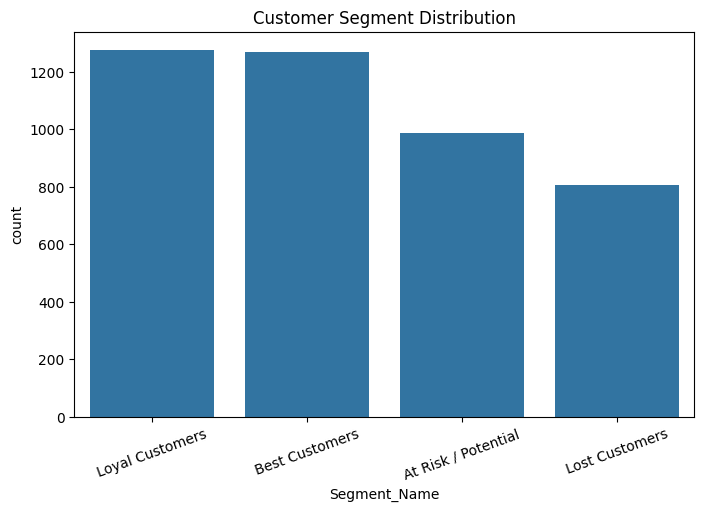

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.countplot(data=rfm, x='Segment_Name', order=rfm['Segment_Name'].value_counts().index)
plt.title('Customer Segment Distribution')
plt.xticks(rotation=20)
plt.show()

## 10. Visualization – Revenue Contribution by Segment

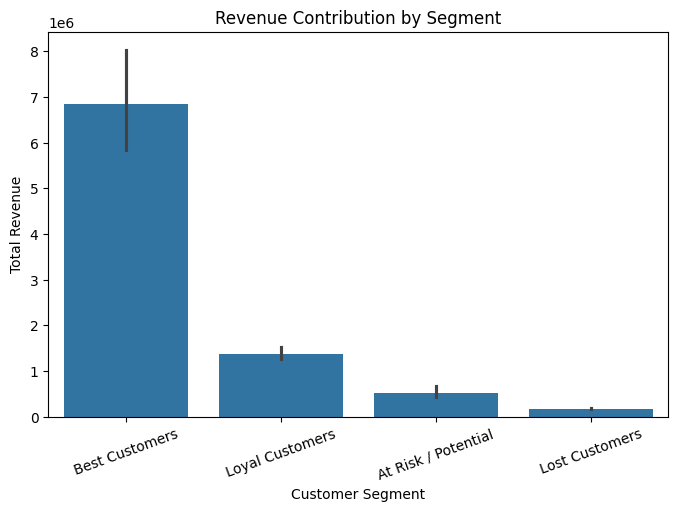

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

# Use 'Segment_Name' to match your dataframe
sns.barplot(
    data=rfm, 
    x='Segment_Name', 
    y='Monetary', 
    estimator=sum,
    order=rfm.groupby('Segment_Name')['Monetary'].sum().sort_values(ascending=False).index
)

plt.title('Revenue Contribution by Segment')
plt.ylabel('Total Revenue')
plt.xlabel('Customer Segment')
plt.xticks(rotation=20)
plt.show()

## 11. RFM Heatmap (Segment Behavior)


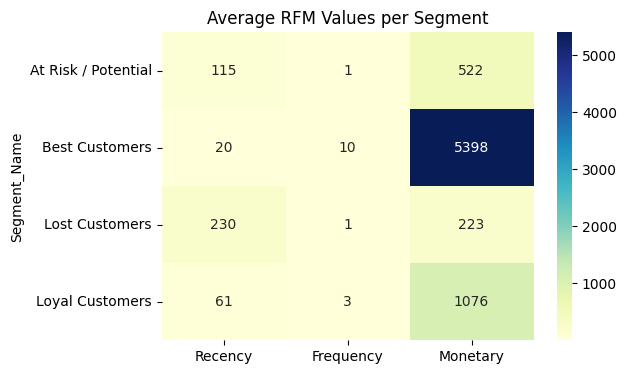

In [25]:
segment_means = rfm.groupby('Segment_Name')[['Recency','Frequency','Monetary']].mean()
plt.figure(figsize=(6,4))
sns.heatmap(segment_means, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Average RFM Values per Segment')
plt.show()

## 12. Business Insights & Marketing Strategy

- **Best Customers:** VIP rewards, early access to sales
- **Loyal Customers:** Loyalty programs, personalized discounts
- **At Risk:** Reminder emails, limited-time offers
- **Lost Customers:** Win-back campaigns or surveys
